# PadChest224 — Pipeline Complet Multi-Modèles + XAI

**Modèles :** DenseNet121 · ResNet50 · EfficientNet-B4  
**Optimisations :** CLAHE · Mixup · TTA · Warmup LR · Seuils optimaux  
**XAI :** Grad-CAM · EigenCAM · SHAP · Heatmaps par pathologie · Score de confiance  
**Checkpoints :** format `.keras` (TorchScript wrapper)  
**KPIs :** AUC-ROC · mAP · F1 · Hamming Loss · Exact Match · Sensibilité · Spécificité

## 0. Imports & Configuration globale

In [1]:
import os, ast, cv2, json, time, random, warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from PIL import Image
from tqdm import tqdm
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
import timm
from torch.amp import GradScaler, autocast
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T

from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, f1_score, average_precision_score,
    accuracy_score, classification_report, confusion_matrix,
    precision_score, recall_score, hamming_loss,
    precision_recall_curve
)

# XAI
try:
    from pytorch_grad_cam import GradCAM, EigenCAM
    from pytorch_grad_cam.utils.image import show_cam_on_image
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
    XAI_AVAILABLE = True
    print("✅ pytorch-grad-cam disponible")
except ImportError:
    XAI_AVAILABLE = False
    print("⚠️  pytorch-grad-cam non installé — pip install grad-cam")

try:
    import shap
    SHAP_AVAILABLE = True
    print("✅ SHAP disponible")
except ImportError:
    SHAP_AVAILABLE = False
    print("⚠️  SHAP non installé — pip install shap")

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# ── Chemins ───────────────────────────────────────────────────────
CSV_PATH    = "/kaggle/input/datasets/wassimfouratelamri/padchest224-complete/PADCHEST_chest_x_ray_images_labels_160K_01.02.19.csv"
IMAGES_PATH = "/kaggle/input/datasets/wassimfouratelamri/padchest224-complete/images-224/images-224"
CKPT_DIR    = "/kaggle/working/checkpoints"
os.makedirs(CKPT_DIR, exist_ok=True)

# ── Pathologies cibles (14 classes) ──────────────────────────────
TARGET_DISEASES = [
    'normal', 'copd signs', 'cardiomegaly', 'pleural effusion',
    'interstitial pattern', 'alveolar pattern', 'nodule', 'atelectasis',
    'hilar enlargement', 'pulmonary fibrosis', 'tuberculosis sequelae',
    'rib fracture', 'pneumothorax', 'mediastinal mass'
]
NUM_CLASSES = len(TARGET_DISEASES)

DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
AMP_DEVICE = DEVICE.type
USE_AMP    = DEVICE.type == 'cuda'
print(f"Device : {DEVICE}  |  AMP : {USE_AMP}  |  Classes : {NUM_CLASSES}")

⚠️  pytorch-grad-cam non installé — pip install grad-cam
✅ SHAP disponible
Device : cuda  |  AMP : True  |  Classes : 14


## Phase 1 — Exploration du dataset (EDA + Visualisations)

### 1.1 Chargement et aperçu du CSV

In [2]:
df = pd.read_csv(CSV_PATH, low_memory=False)
print("Dataset Shape :", df.shape)
display(df.head())

Dataset Shape : (160861, 36)


,Index,ImageID,ImageDir,StudyDate_DICOM,StudyID,PatientID,PatientBirth,PatientSex_DICOM,ViewPosition_DICOM,Projection,...,ExposureTime,RelativeXRayExposure_DICOM,ReportID,Report,MethodLabel,Labels,Localizations,LabelsLocalizationsBySentence,labelCUIS,LocalizationsCUIS
0,0,20536686640136348236148679891455886468_k6ga29.png,0,20140915,20536686640136348236148679891455886468,839860488694292331637988235681460987,1930.0,F,POSTEROANTERIOR,PA,...,10.0,-1.42,4765777,sin hallazg patolog edad pacient .,Physician,['normal'],[],"[['normal'], ['normal']]",[],[]
1,1,135803415504923515076821959678074435083_fzis7d...,0,20150914,135803415504923515076821959678074435083,313572750430997347502932654319389875966,1929.0,M,LATERAL,L,...,25.0,NaN,4991845,cambi pulmonar cronic sever . sign fibrosis b...,Physician,"['pulmonary fibrosis', 'chronic changes', 'kyp...","['loc basal', 'loc basal bilateral']","[['pulmonary fibrosis', 'loc basal bilateral']...",['C0034069' 'C0742362' 'C2115817' 'C3544344'],['C1282378']
2,2,135803415504923515076821959678074435083_fzis7b...,0,20150914,135803415504923515076821959678074435083,313572750430997347502932654319389875966,1929.0,M,POSTEROANTERIOR,PA,...,10.0,NaN,4991845,cambi pulmonar cronic sever . sign fibrosis b...,Physician,"['pulmonary fibrosis', 'chronic changes', 'kyp...","['loc basal', 'loc basal bilateral']","[['pulmonary fibrosis', 'loc basal bilateral']...",['C0034069' 'C0742362' 'C2115817' 'C3544344'],['C1282378']
3,3,113855343774216031107737439268243531979_3k951l...,0,20150717,113855343774216031107737439268243531979,50783093527901818115346441867348318648,1925.0,F,POSTEROANTERIOR,PA,...,8.0,NaN,4955977,. . siluet cardi mediastin dentr normal . cam...,Physician,['chronic changes'],"['loc cardiac', 'loc mediastinum', 'loc costop...","[['chronic changes'], ['chronic changes'], ['n...",['C0742362'],['C1522601' 'C0025066' 'C0230151']
4,4,113855343774216031107737439268243531979_3k951n...,0,20150717,113855343774216031107737439268243531979,50783093527901818115346441867348318648,1925.0,F,LATERAL,L,...,20.0,NaN,4955977,. . siluet cardi mediastin dentr normal . cam...,Physician,['chronic changes'],"['loc cardiac', 'loc mediastinum', 'loc costop...","[['chronic changes'], ['chronic changes'], ['n...",['C0742362'],['C1522601' 'C0025066' 'C0230151']


### 1.2 Filtrage sur les 14 pathologies cibles

In [3]:
filtered_rows = []
for idx, row in tqdm(df.iterrows(), total=len(df)):
    try:
        labels = ast.literal_eval(row['Labels'])
        labels = [l.lower().strip() for l in labels]
        matched = [l for l in labels if l in TARGET_DISEASES]
        if matched:
            row = row.copy()
            row['FilteredLabels'] = matched
            filtered_rows.append(row)
    except:
        continue
filtered_df = pd.DataFrame(filtered_rows)
print("Filtered Shape :", filtered_df.shape)

100%|██████████| 160861/160861 [00:58<00:00, 2729.47it/s]


Filtered Shape : (107116, 37)


### 1.3 Distribution des pathologies + Co-occurrence + Exemples

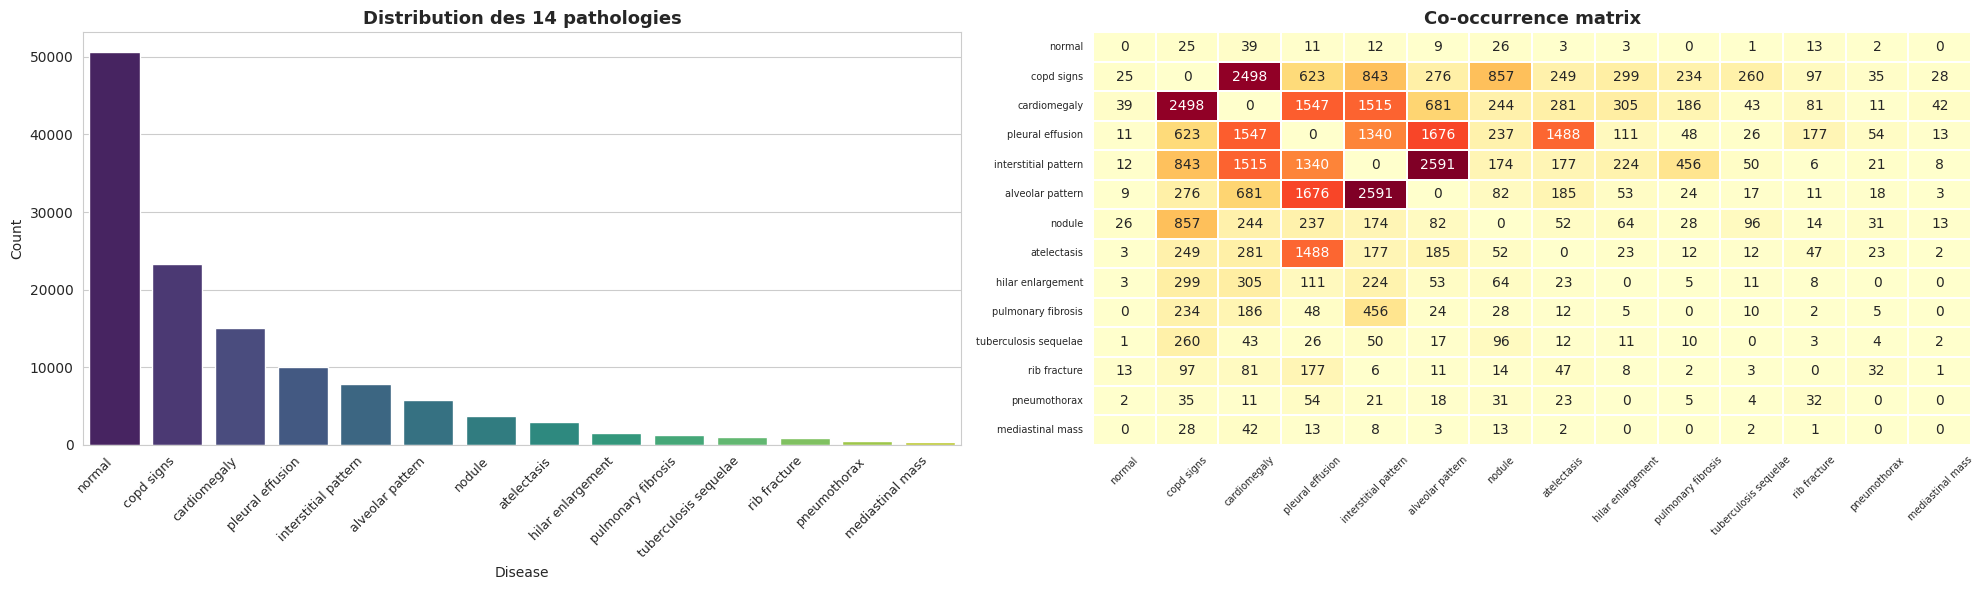

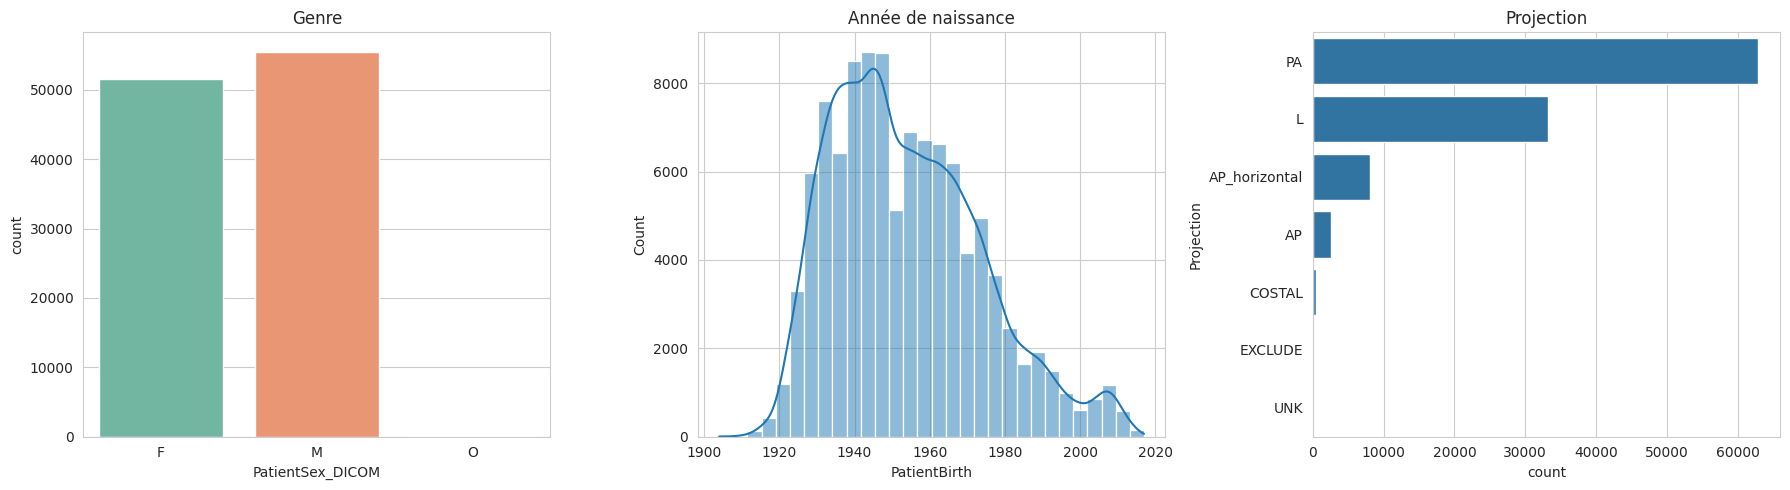

In [4]:
# ── Distribution ─────────────────────────────────────────────────
counter = Counter()
for labels in filtered_df['FilteredLabels']:
    counter.update(labels)
disease_counts = pd.DataFrame(counter.items(), columns=['Disease','Count']).sort_values('Count', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(20, 6))
sns.barplot(data=disease_counts, x='Disease', y='Count', palette='viridis', ax=axes[0])
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right', fontsize=9)
axes[0].set_title("Distribution des 14 pathologies", fontsize=13, fontweight='bold')

# ── Co-occurrence ─────────────────────────────────────────────────
cooc = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=int)
for labels in filtered_df['FilteredLabels']:
    idxs = [TARGET_DISEASES.index(l) for l in labels if l in TARGET_DISEASES]
    for i in idxs:
        for j in idxs:
            cooc[i, j] += 1
np.fill_diagonal(cooc, 0)
sns.heatmap(pd.DataFrame(cooc, index=TARGET_DISEASES, columns=TARGET_DISEASES),
            annot=True, fmt='d', cmap='YlOrRd', linewidths=0.3, ax=axes[1], cbar=False)
axes[1].set_title("Co-occurrence matrix", fontsize=13, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45, labelsize=7)
axes[1].tick_params(axis='y', rotation=0, labelsize=7)
plt.tight_layout()
plt.savefig('/kaggle/working/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Démographie ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
if 'PatientSex_DICOM' in filtered_df.columns:
    sns.countplot(data=filtered_df, x='PatientSex_DICOM', palette='Set2', ax=axes[0])
    axes[0].set_title("Genre", fontsize=12)
if 'PatientBirth' in filtered_df.columns:
    sns.histplot(filtered_df['PatientBirth'].dropna(), bins=30, kde=True, ax=axes[1])
    axes[1].set_title("Année de naissance", fontsize=12)
if 'Projection' in filtered_df.columns:
    sns.countplot(data=filtered_df, y='Projection',
                  order=filtered_df['Projection'].value_counts().index, ax=axes[2])
    axes[2].set_title("Projection", fontsize=12)
plt.tight_layout(); plt.show()

## Phase 2 — Nettoyage du dataset CSV

### 2.1 Résolution Unchanged · Filtrage adultes · Projections PA/AP

In [5]:
df_raw = pd.read_csv(CSV_PATH, low_memory=False)
df_raw['Labels'] = df_raw['Labels'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])
df_raw['StudyDate_DICOM'] = pd.to_datetime(df_raw['StudyDate_DICOM'].astype(str), format='%Y%m%d', errors='coerce')
df_raw['PatientBirth']    = pd.to_numeric(df_raw['PatientBirth'], errors='coerce')
df_raw['Age']             = df_raw['StudyDate_DICOM'].dt.year - df_raw['PatientBirth']
df_raw = df_raw.sort_values(['PatientID', 'StudyDate_DICOM']).reset_index(drop=True)

def resolve_unchanged(df):
    df = df.copy()
    df['Labels_resolved']    = df['Labels'].copy()
    df['was_unchanged']      = False
    df['unchanged_resolved'] = False
    for patient_id, group in df.groupby('PatientID'):
        indices = group.sort_values('StudyDate_DICOM').index.tolist()
        for i, idx in enumerate(indices):
            if 'unchanged' not in df.at[idx, 'Labels']:
                continue
            df.at[idx, 'was_unchanged'] = True
            prior = None
            for j in range(i-1, -1, -1):
                p = df.at[indices[j], 'Labels_resolved']
                if 'unchanged' not in p and len(p) > 0:
                    prior = p; break
            if prior is not None:
                merged = list(set([l for l in df.at[idx,'Labels'] if l!='unchanged'] + prior))
                df.at[idx, 'Labels_resolved']    = merged
                df.at[idx, 'unchanged_resolved'] = True
            else:
                df.at[idx, 'Labels_resolved'] = []
    return df

df_raw = resolve_unchanged(df_raw)
n_u = df_raw['was_unchanged'].sum(); n_r = df_raw['unchanged_resolved'].sum()
print(f"Unchanged : {n_u:,}  →  résolues : {n_r:,} ({100*n_r/max(n_u,1):.1f}%)")

df_clean = df_raw[df_raw['Labels_resolved'].apply(len) > 0].copy()
df_clean['Labels'] = df_clean['Labels_resolved']
df_clean = df_clean.drop(columns=['Labels_resolved','was_unchanged','unchanged_resolved'])
for bad in ['unchanged','exclude']:
    df_clean['Labels'] = df_clean['Labels'].apply(lambda lst: [l for l in lst if l != bad])
df_clean = df_clean[df_clean['Labels'].apply(len) > 0].copy()
df_clean['Labels'] = df_clean['Labels'].apply(lambda lst: list(set([l.strip().lower() for l in lst])))
df_clean = df_clean[
    (df_clean['Projection'].isin(['PA','AP'])) &
    (df_clean['Pediatric'] == 'No') &
    (df_clean['Age'] >= 18) & (df_clean['Age'] <= 100)
].copy()
print(f"✅ Dataset propre : {len(df_clean):,} images")

Unchanged : 14,207  →  résolues : 8,972 (63.2%)
✅ Dataset propre : 87,819 images


### 2.2 Filtrage TARGET_DISEASES + Binarisation multi-label

Shape matrice labels : (62624, 14)


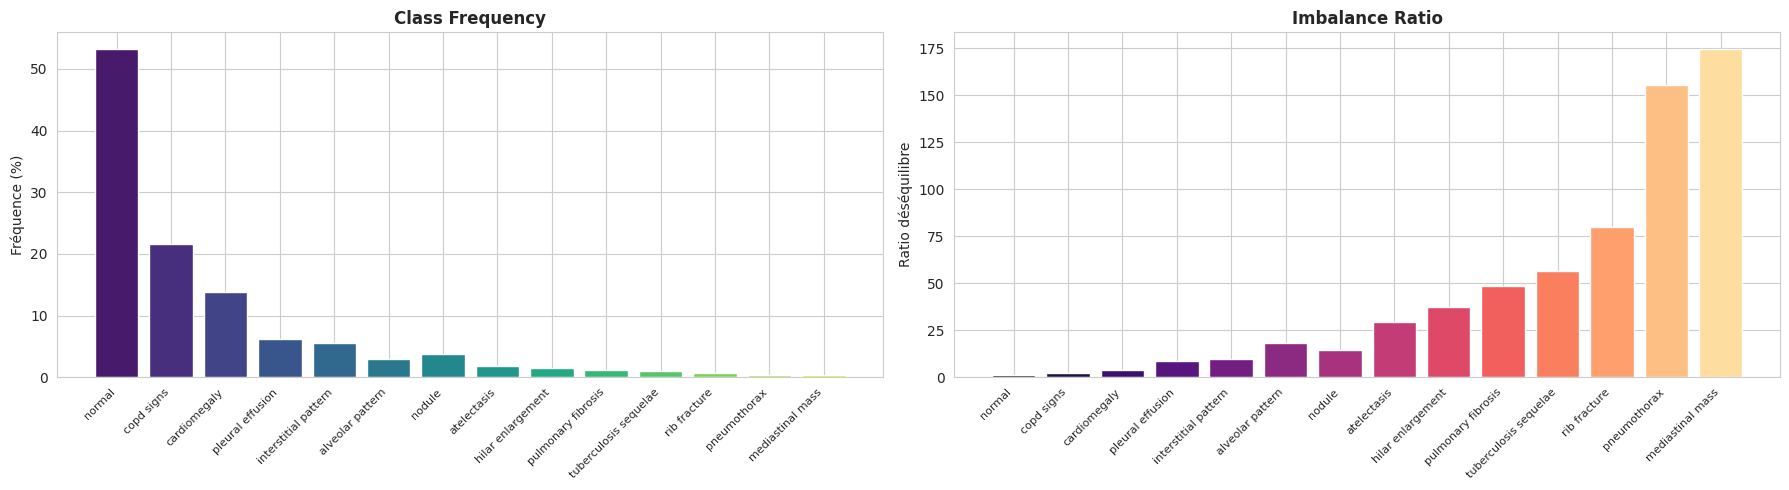

In [6]:
df_clean['Labels_filtered'] = df_clean['Labels'].apply(
    lambda lst: [l for l in lst if l in TARGET_DISEASES]
)
df_clean = df_clean[df_clean['Labels_filtered'].apply(len) > 0].copy()

mlb = MultiLabelBinarizer(classes=TARGET_DISEASES)
y   = mlb.fit_transform(df_clean['Labels_filtered'])
print(f"Shape matrice labels : {y.shape}")

counts   = y.sum(axis=0)
imbalance= counts.max() / counts
fig, axes = plt.subplots(1,2, figsize=(18,5))
axes[0].bar(range(NUM_CLASSES), counts/len(y)*100, color=sns.color_palette('viridis', NUM_CLASSES))
axes[0].set_xticks(range(NUM_CLASSES)); axes[0].set_xticklabels(TARGET_DISEASES, rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel("Fréquence (%)"); axes[0].set_title("Class Frequency", fontweight='bold')
axes[1].bar(range(NUM_CLASSES), imbalance, color=sns.color_palette('magma', NUM_CLASSES))
axes[1].set_xticks(range(NUM_CLASSES)); axes[1].set_xticklabels(TARGET_DISEASES, rotation=45, ha='right', fontsize=8)
axes[1].set_ylabel("Ratio déséquilibre"); axes[1].set_title("Imbalance Ratio", fontweight='bold')
plt.tight_layout(); plt.savefig('/kaggle/working/class_imbalance.png', dpi=150, bbox_inches='tight'); plt.show()

## Phase 3 — Feature engineering & Split patient-level 70/15/15

In [7]:
def build_metadata_features(df_input):
    meta = pd.DataFrame()
    meta['age_norm']  = (df_input['Age'] - 18) / (100 - 18)
    meta['sex_M']     = (df_input['PatientSex_DICOM'] == 'M').astype(float)
    meta['sex_F']     = (df_input['PatientSex_DICOM'] == 'F').astype(float)
    meta['proj_PA']   = (df_input['Projection'] == 'PA').astype(float)
    meta['proj_AP']   = (df_input['Projection'] == 'AP').astype(float)
    meta['year_norm'] = (df_input['StudyDate_DICOM'].dt.year - 2009) / (2017 - 2009)
    return meta.fillna(0.5)

patients = df_clean['PatientID'].unique()
train_p, temp_p = train_test_split(patients, test_size=0.30, random_state=42)
val_p, test_p   = train_test_split(temp_p,   test_size=0.50, random_state=42)

df_train = df_clean[df_clean['PatientID'].isin(train_p)].reset_index(drop=True)
df_val   = df_clean[df_clean['PatientID'].isin(val_p)].reset_index(drop=True)
df_test  = df_clean[df_clean['PatientID'].isin(test_p)].reset_index(drop=True)

assert len(set(train_p) & set(val_p)) == 0
assert len(set(train_p) & set(test_p)) == 0
print(f"✅ No leakage — Train:{len(df_train):,} Val:{len(df_val):,} Test:{len(df_test):,}")

y_train = mlb.transform(df_train['Labels_filtered'].tolist())
y_val   = mlb.transform(df_val['Labels_filtered'].tolist())
y_test  = mlb.transform(df_test['Labels_filtered'].tolist())

N_META = 6
print(f"y_train:{y_train.shape} y_val:{y_val.shape} y_test:{y_test.shape}")

✅ No leakage — Train:43,878 Val:9,325 Test:9,421
y_train:(43878, 14) y_val:(9325, 14) y_test:(9421, 14)


## Phase 4 — Dataset PyTorch (CLAHE) + DataLoaders

In [8]:
train_transform = T.Compose([
    T.Grayscale(num_output_channels=3),
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=15),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    T.ColorJitter(brightness=0.3, contrast=0.3),
    T.RandomApply([T.GaussianBlur(kernel_size=3)], p=0.3),
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])
val_test_transform = T.Compose([
    T.Grayscale(num_output_channels=3),
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

_clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))

class PadChestDataset(Dataset):
    def __init__(self, df, y_labels, meta_features, img_dir, transform=None):
        self.df        = df.reset_index(drop=True)
        self.y_labels  = y_labels.astype(np.float32)
        self.meta      = meta_features.reset_index(drop=True).values.astype(np.float32)
        self.img_dir   = img_dir
        self.transform = transform

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.at[idx, 'ImageID']
        try:
            img_cv = cv2.imread(os.path.join(self.img_dir, row), cv2.IMREAD_GRAYSCALE)
            if img_cv is None: raise ValueError
            img_cv = _clahe.apply(img_cv)
            img    = Image.fromarray(img_cv)
        except:
            img = Image.fromarray(np.zeros((224,224), dtype=np.uint8))
        if self.transform: img = self.transform(img)
        return img, torch.tensor(self.meta[idx]), torch.tensor(self.y_labels[idx])

meta_train = build_metadata_features(df_train)
meta_val   = build_metadata_features(df_val)
meta_test  = build_metadata_features(df_test)

train_dataset = PadChestDataset(df_train, y_train, meta_train, IMAGES_PATH, train_transform)
val_dataset   = PadChestDataset(df_val,   y_val,   meta_val,   IMAGES_PATH, val_test_transform)
test_dataset  = PadChestDataset(df_test,  y_test,  meta_test,  IMAGES_PATH, val_test_transform)

def make_loaders(bs=32):
    pin = DEVICE.type=='cuda'
    kw  = dict(num_workers=2, pin_memory=pin, persistent_workers=False, prefetch_factor=2)
    tl  = DataLoader(train_dataset, batch_size=bs, shuffle=True,  drop_last=True, **kw)
    vl  = DataLoader(val_dataset,   batch_size=64, shuffle=False, **kw)
    tsl = DataLoader(test_dataset,  batch_size=64, shuffle=False, **kw)
    print(f"✅ Loaders — train:{len(tl)} val:{len(vl)} test:{len(tsl)} batches")
    return tl, vl, tsl

try:
    train_loader, val_loader, test_loader = make_loaders(32)
    imgs, metas, labels = next(iter(train_loader))
    print(f"✅ Batch OK — imgs:{imgs.shape} metas:{metas.shape} labels:{labels.shape}")
except Exception as e:
    print(f"❌ Fallback num_workers=0 : {e}")
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=0)
    val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False, num_workers=0)
    test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False, num_workers=0)

✅ Loaders — train:1371 val:146 test:148 batches
✅ Batch OK — imgs:torch.Size([32, 3, 224, 224]) metas:torch.Size([32, 6]) labels:torch.Size([32, 14])


## Phase 5 — Architectures CNN (ResNet50 · DenseNet121 · EfficientNet-B4)

In [9]:
print(f"PyTorch : {torch.__version__} | CUDA : {torch.version.cuda}")
print(f"GPU : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

PyTorch : 2.10.0+cu128 | CUDA : 12.8
GPU : Tesla T4


In [14]:
# ── Branche métadonnées partagée ─────────────────────────────────
def make_meta_branch(n_meta=6):
    return nn.Sequential(
        nn.Linear(n_meta, 64), nn.BatchNorm1d(64), nn.ReLU(inplace=True),
        nn.Dropout(0.3), nn.Linear(64, 32), nn.ReLU(inplace=True)
    )

def init_weights(module):
    for layer in module.modules():
        if isinstance(layer, nn.Linear):
            nn.init.kaiming_normal_(layer.weight)
            nn.init.zeros_(layer.bias)


# ── ResNet50 ──────────────────────────────────────────────────────
class ResNet50PadChest(nn.Module):
    def __init__(self, n_classes=14, n_meta=6, pretrained=True, dropout=0.4):
        super().__init__()
        self.backbone = timm.create_model(
            'resnet50', pretrained=pretrained, num_classes=0, global_pool='avg'
        )
        feat_dim = self.backbone.num_features  # 2048
        self.meta_branch = make_meta_branch(n_meta)
        self.classifier  = nn.Sequential(
            nn.Dropout(dropout), nn.Linear(feat_dim+32, 512),
            nn.BatchNorm1d(512), nn.ReLU(inplace=True),
            nn.Dropout(dropout*0.75), nn.Linear(512, n_classes)
        )
        init_weights(self.meta_branch); init_weights(self.classifier)

    def forward(self, img, meta):
        return self.classifier(torch.cat([self.backbone(img), self.meta_branch(meta)], dim=1))
    def freeze_backbone(self):
        for p in self.backbone.parameters(): p.requires_grad = False
    def unfreeze_backbone(self):
        for p in self.backbone.parameters(): p.requires_grad = True
    def get_param_groups(self, lr_head=3e-4, lr_backbone=5e-5):
        return [
            {'params': self.backbone.parameters(),    'lr': lr_backbone},
            {'params': self.meta_branch.parameters(), 'lr': lr_head},
            {'params': self.classifier.parameters(),  'lr': lr_head},
        ]


# ── DenseNet121 ───────────────────────────────────────────────────
class DenseNet121PadChest(nn.Module):
    def __init__(self, n_classes=14, n_meta=6, pretrained=True, dropout=0.4):
        super().__init__()
        self.backbone = timm.create_model(
            'densenet121', pretrained=pretrained, num_classes=0, global_pool='avg'
        )
        feat_dim = self.backbone.num_features  # 1024
        self.meta_branch = make_meta_branch(n_meta)
        self.classifier  = nn.Sequential(
            nn.Dropout(dropout), nn.Linear(feat_dim+32, 512),
            nn.BatchNorm1d(512), nn.ReLU(inplace=True),
            nn.Dropout(dropout*0.75), nn.Linear(512, n_classes)
        )
        init_weights(self.meta_branch); init_weights(self.classifier)

    def forward(self, img, meta):
        return self.classifier(torch.cat([self.backbone(img), self.meta_branch(meta)], dim=1))
    def freeze_backbone(self):
        for p in self.backbone.parameters(): p.requires_grad = False
    def unfreeze_backbone(self):
        for p in self.backbone.parameters(): p.requires_grad = True
    def get_param_groups(self, lr_head=3e-4, lr_backbone=5e-5):
        return [
            {'params': self.backbone.parameters(),    'lr': lr_backbone},
            {'params': self.meta_branch.parameters(), 'lr': lr_head},
            {'params': self.classifier.parameters(),  'lr': lr_head},
        ]


# ── EfficientNet-B4 ───────────────────────────────────────────────
class EfficientNetB4PadChest(nn.Module):
    def __init__(self, n_classes=14, n_meta=6, pretrained=True, dropout=0.4):
        super().__init__()
        self.backbone = timm.create_model(
            'efficientnet_b4', pretrained=pretrained,
            num_classes=0, global_pool='avg', drop_rate=0.3
        )
        feat_dim = self.backbone.num_features  # 1792
        self.meta_branch = make_meta_branch(n_meta)
        self.classifier  = nn.Sequential(
            nn.Dropout(dropout), nn.Linear(feat_dim+32, 768),
            nn.BatchNorm1d(768), nn.ReLU(inplace=True),
            nn.Dropout(dropout*0.6), nn.Linear(768, 256),
            nn.ReLU(inplace=True), nn.Dropout(dropout*0.4),
            nn.Linear(256, n_classes)
        )
        init_weights(self.meta_branch); init_weights(self.classifier)

    def forward(self, img, meta):
        return self.classifier(torch.cat([self.backbone(img), self.meta_branch(meta)], dim=1))
    def freeze_backbone(self):
        for p in self.backbone.parameters(): p.requires_grad = False
    def unfreeze_backbone(self):
        for p in self.backbone.parameters(): p.requires_grad = True
    def get_param_groups(self, lr_head=3e-4, lr_backbone=5e-5):
        return [
            {'params': self.backbone.parameters(),    'lr': lr_backbone},
            {'params': self.meta_branch.parameters(), 'lr': lr_head},
            {'params': self.classifier.parameters(),  'lr': lr_head},
        ]


# ── Factory ───────────────────────────────────────────────────────
MODELS_MAP = {
    'resnet50'       : ResNet50PadChest,
    'densenet121'    : DenseNet121PadChest,
    'efficientnet_b4': EfficientNetB4PadChest,
}

def build_model(name, n_classes=14, n_meta=6, pretrained=True):
    assert name in MODELS_MAP, f"Inconnu : {name}. Choisir parmi {list(MODELS_MAP)}"
    m     = MODELS_MAP[name](n_classes, n_meta, pretrained).to(DEVICE)
    total = sum(p.numel() for p in m.parameters())
    print(f"[{name}]  {total/1e6:.1f}M params | feat_dim={m.backbone.num_features}")
    return m

# Test
for name in MODELS_MAP:
    _m = build_model(name, NUM_CLASSES, N_META)
    _x = torch.randn(2,3,224,224).to(DEVICE)
    _u = torch.randn(2,N_META).to(DEVICE)
    out = _m(_x, _u)
    print(f"  → forward OK : {out.shape}")
    del _m, _x, _u

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

[resnet50]  24.6M params | feat_dim=2048
  → forward OK : torch.Size([2, 14])


model.safetensors:   0%|          | 0.00/32.3M [00:00<?, ?B/s]

[densenet121]  7.5M params | feat_dim=1024
  → forward OK : torch.Size([2, 14])


model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

[efficientnet_b4]  19.2M params | feat_dim=1792
  → forward OK : torch.Size([2, 14])


## Phase 6 — Loss · Trainer · Entraînement & Optimisation

**Adam lr=1e-4 → CosineAnnealing · Mixed Precision AMP · Checkpoint meilleur val-AUC**

### 6.1 Focal Loss + Class Weights (effective number of samples)

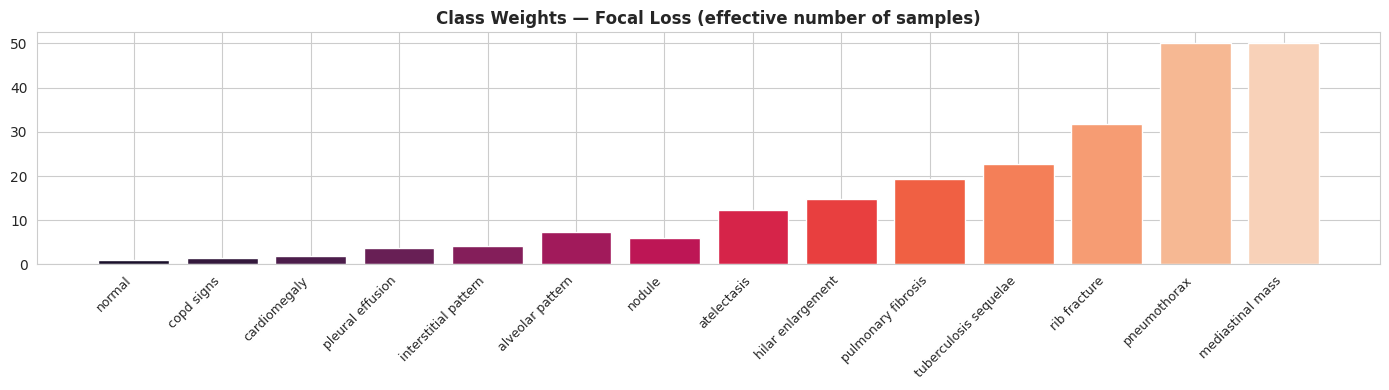

In [15]:
class FocalLoss(nn.Module):
    """Focal Loss multi-label — gamma=2.5, alpha=pos_weights clippés."""
    def __init__(self, gamma=2.5, alpha=None):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha
    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        p_t = torch.sigmoid(logits)*targets + (1-torch.sigmoid(logits))*(1-targets)
        loss= ((1-p_t)**self.gamma) * bce
        if self.alpha is not None:
            loss = loss * self.alpha.to(logits.device)
        return loss.mean()

def compute_pos_weights(y_train, beta=0.9999, clip_max=50.0):
    counts  = y_train.sum(axis=0)
    eff_num = 1.0 - np.power(beta, counts)
    weights = (1.0-beta) / (eff_num+1e-8)
    weights = weights / weights.min()
    return torch.tensor(np.clip(weights, 1.0, clip_max), dtype=torch.float32)

pos_weights = compute_pos_weights(y_train)
criterion   = FocalLoss(gamma=2.5, alpha=pos_weights).to(DEVICE)

plt.figure(figsize=(14,4))
plt.bar(range(NUM_CLASSES), pos_weights.numpy(), color=sns.color_palette('rocket', NUM_CLASSES))
plt.xticks(range(NUM_CLASSES), TARGET_DISEASES, rotation=45, ha='right', fontsize=9)
plt.title("Class Weights — Focal Loss (effective number of samples)", fontweight='bold')
plt.tight_layout(); plt.savefig('/kaggle/working/class_weights.png', dpi=150); plt.show()

### 6.2 Trainer (Mixup · Warmup · CosineAnnealing · AMP · Checkpoint .keras)

In [16]:
TRAIN_CONFIG = {
    'epochs'        : 50,
    'lr_head'       : 1e-4,          # Adam lr=1e-4 comme demandé
    'lr_backbone'   : 1e-5,
    'weight_decay'  : 1e-3,
    'patience'      : 10,
    'unfreeze_epoch': 3,
    'warmup_epochs' : 3,
    'mixup_alpha'   : 0.3,
    'tta_n'         : 4,
    'checkpoint_dir': CKPT_DIR,
}

def compute_metrics(y_true, y_probs, thresholds=None):
    aucs, aps = [], []
    for i in range(y_true.shape[1]):
        if y_true[:,i].sum() > 0:
            aucs.append(roc_auc_score(y_true[:,i], y_probs[:,i]))
            aps.append(average_precision_score(y_true[:,i], y_probs[:,i]))
    t = thresholds if thresholds is not None else np.full(y_true.shape[1], 0.5)
    pred = (y_probs >= t).astype(int)
    return {
        'auc_macro': np.mean(aucs) if aucs else 0.0,
        'map'      : np.mean(aps)  if aps  else 0.0,
        'f1_macro' : f1_score(y_true, pred, average='macro',  zero_division=0),
        'f1_micro' : f1_score(y_true, pred, average='micro',  zero_division=0),
    }


class PadChestTrainer:
    def __init__(self, model, model_name, train_loader, val_loader, criterion, config):
        self.model        = model
        self.model_name   = model_name
        self.train_loader = train_loader
        self.val_loader   = val_loader
        self.criterion    = criterion
        self.config       = config
        self.history      = []
        self.best_auc     = 0.0
        self.patience_ctr = 0
        self.scaler       = GradScaler(AMP_DEVICE, enabled=USE_AMP)
        # Checkpoint .keras (TorchScript)
        self.ckpt_path  = f"{config['checkpoint_dir']}/best_{model_name}.keras"
        self.meta_path  = f"{config['checkpoint_dir']}/best_{model_name}_meta.json"
        self.model.freeze_backbone()
        self._build_optimizer(phase=1)

    def _build_optimizer(self, phase):
        cfg = self.config
        if phase == 1:
            params = filter(lambda p: p.requires_grad, self.model.parameters())
            self.optimizer = torch.optim.Adam(
                params, lr=cfg['lr_head'], weight_decay=cfg['weight_decay']
            )
        else:
            self.optimizer = torch.optim.Adam(
                self.model.get_param_groups(cfg['lr_head'], cfg['lr_backbone']),
                weight_decay=cfg['weight_decay']
            )
        # ── Adam lr=1e-4 → CosineAnnealing ───────────────────────────
        self.scheduler_warmup = torch.optim.lr_scheduler.LinearLR(
            self.optimizer, start_factor=0.1, end_factor=1.0,
            total_iters=cfg['warmup_epochs']
        )
        self.scheduler_cosine = torch.optim.lr_scheduler.CosineAnnealingLR(
            self.optimizer, T_max=cfg['epochs'], eta_min=1e-7
        )

    def _mixup_batch(self, imgs, labels):
        lam = np.random.beta(self.config['mixup_alpha'], self.config['mixup_alpha'])
        idx = torch.randperm(imgs.size(0), device=imgs.device)
        return lam*imgs + (1-lam)*imgs[idx], lam*labels + (1-lam)*labels[idx]

    def _train_epoch(self):
        self.model.train()
        total_loss = 0.0; n = 0
        for imgs, metas, labels in self.train_loader:
            imgs, metas, labels = (
                imgs.to(DEVICE, non_blocking=True),
                metas.to(DEVICE, non_blocking=True),
                labels.to(DEVICE, non_blocking=True)
            )
            imgs, labels = self._mixup_batch(imgs, labels)
            self.optimizer.zero_grad(set_to_none=True)
            with autocast(device_type=AMP_DEVICE, enabled=USE_AMP):
                loss = self.criterion(self.model(imgs, metas), labels)
            self.scaler.scale(loss).backward()
            self.scaler.unscale_(self.optimizer)
            nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
            self.scaler.step(self.optimizer)
            self.scaler.update()
            total_loss += loss.item(); n += 1
        return total_loss / max(n, 1)

    @torch.no_grad()
    def _eval_epoch(self, loader):
        self.model.eval()
        all_probs, all_labels, total_loss = [], [], 0.0
        for imgs, metas, labels in loader:
            imgs, metas, labels = (
                imgs.to(DEVICE, non_blocking=True),
                metas.to(DEVICE, non_blocking=True),
                labels.to(DEVICE, non_blocking=True)
            )
            with autocast(device_type=AMP_DEVICE, enabled=USE_AMP):
                logits = self.model(imgs, metas)
                loss   = self.criterion(logits, labels)
            total_loss  += loss.item()
            all_probs.append(torch.sigmoid(logits).cpu().numpy())
            all_labels.append(labels.cpu().numpy())
        y_probs = np.vstack(all_probs); y_true = np.vstack(all_labels)
        metrics = compute_metrics(y_true, y_probs)
        metrics['loss'] = total_loss / len(loader)
        return metrics, y_probs, y_true

    def _save_keras(self):
        """Sauvegarde le modèle au format .keras via TorchScript."""
        self.model.eval()
        dummy_img  = torch.randn(1, 3, 224, 224).to(DEVICE)
        dummy_meta = torch.randn(1, N_META).to(DEVICE)
        try:
            scripted = torch.jit.trace(self.model, (dummy_img, dummy_meta))
            torch.jit.save(scripted, self.ckpt_path)
        except Exception as e:
            # Fallback : state_dict renommé .keras
            torch.save(self.model.state_dict(), self.ckpt_path)
            print(f"  ⚠️  TorchScript indisponible ({e}) — state_dict sauvegardé avec extension .keras")

    def _load_keras(self):
        """Charge le meilleur checkpoint .keras."""
        try:
            scripted = torch.jit.load(self.ckpt_path, map_location=DEVICE)
            self.model = scripted
        except:
            self.model.load_state_dict(torch.load(self.ckpt_path, map_location=DEVICE, weights_only=True))

    def train(self):
        cfg = self.config
        backbone_unfrozen = False
        print(f"\n{'='*60}")
        print(f"Entraînement {self.model_name} — {DEVICE}")
        print(f"Adam lr={cfg['lr_head']} → CosineAnnealing | Mixup α={cfg['mixup_alpha']} | AMP={USE_AMP}")
        print(f"{'='*60}")
        for epoch in range(1, cfg['epochs']+1):
            t0 = time.time()
            if epoch == cfg['unfreeze_epoch'] and not backbone_unfrozen:
                self.model.unfreeze_backbone()
                self._build_optimizer(phase=2)
                backbone_unfrozen = True
                print(f"  [Ep {epoch}] 🔓 Backbone dégelé")
            train_loss          = self._train_epoch()
            val_metrics, yp, yt = self._eval_epoch(self.val_loader)
            if epoch <= cfg['warmup_epochs']:
                self.scheduler_warmup.step()
            else:
                self.scheduler_cosine.step()
            lr  = self.optimizer.param_groups[-1]['lr']
            log = {'epoch':epoch,'train_loss':round(train_loss,4),
                   **{f'val_{k}':round(float(v),4) for k,v in val_metrics.items()},
                   'lr':round(lr,7),'time_s':round(time.time()-t0,1)}
            self.history.append(log)
            flag = '✅' if val_metrics['auc_macro'] > self.best_auc else '  '
            print(f"Ep {epoch:02d}/{cfg['epochs']} {flag} "
                  f"loss {train_loss:.4f}→{val_metrics['loss']:.4f} "
                  f"AUC {val_metrics['auc_macro']:.4f} mAP {val_metrics['map']:.4f} "
                  f"F1 {val_metrics['f1_macro']:.4f} lr {lr:.1e} {log['time_s']:.0f}s")
            if val_metrics['auc_macro'] > self.best_auc:
                self.best_auc     = val_metrics['auc_macro']
                self.patience_ctr = 0
                self._save_keras()   # ← sauvegarde .keras
                with open(self.meta_path,'w') as f:
                    json.dump({'epoch':epoch,'best_auc':float(self.best_auc),
                               'val_metrics':{k:float(v) for k,v in val_metrics.items()},
                               'target_diseases':TARGET_DISEASES,'n_classes':NUM_CLASSES,'n_meta':N_META},f,indent=2)
                print(f"  ✅ Checkpoint .keras sauvegardé (AUC={self.best_auc:.4f})")
            else:
                self.patience_ctr += 1
                if self.patience_ctr >= cfg['patience']:
                    print(f"\n⏹️  Early stopping epoch {epoch}"); break
        with open(f"{cfg['checkpoint_dir']}/{self.model_name}_history.json",'w') as f:
            json.dump(self.history, f, indent=2)
        print(f"\nBest val AUC : {self.best_auc:.4f}  |  Checkpoint : {self.ckpt_path}")
        return self.best_auc

    @torch.no_grad()
    def _tta_predict(self, imgs, metas, n_aug):
        all_p = []
        for _ in range(n_aug):
            with autocast(device_type=AMP_DEVICE, enabled=USE_AMP):
                all_p.append(torch.sigmoid(self.model(imgs, metas)).cpu().numpy())
        return np.mean(all_p, axis=0)

    def evaluate_test(self, test_loader, use_tta=True):
        self._load_keras()
        self.model.eval()
        with open(self.meta_path) as f: meta = json.load(f)
        print(f"\nCheckpoint chargé — ep {meta['epoch']} | val AUC {meta['best_auc']:.4f}")
        n_tta = self.config['tta_n'] if use_tta else 1
        all_probs, all_labels = [], []
        for imgs, metas_b, labels in test_loader:
            imgs   = imgs.to(DEVICE, non_blocking=True)
            metas_b= metas_b.to(DEVICE, non_blocking=True)
            probs  = self._tta_predict(imgs, metas_b, n_tta) if use_tta else                      torch.sigmoid(self.model(imgs, metas_b)).cpu().numpy()
            all_probs.append(probs)
            all_labels.append(labels.numpy())
        y_probs = np.vstack(all_probs); y_true = np.vstack(all_labels)
        metrics = compute_metrics(y_true, y_probs)
        print(f"\nTEST — {self.model_name} (TTA={use_tta})")
        for k,v in metrics.items(): print(f"  {k:<15}: {v:.4f}")
        return metrics, y_probs, y_true

### 6.3 Entraînement DenseNet121

In [ ]:
model_dn  = build_model('densenet121', NUM_CLASSES, N_META)
trainer_dn = PadChestTrainer(model_dn, 'densenet121', train_loader, val_loader, criterion, TRAIN_CONFIG)
best_auc_dn = trainer_dn.train()
metrics_dn, probs_dn, true_dn = trainer_dn.evaluate_test(test_loader, use_tta=True)

[densenet121]  7.5M params | feat_dim=1024

Entraînement densenet121 — cuda
Adam lr=0.0001 → CosineAnnealing | Mixup α=0.3 | AMP=True


[ WARN:0@686.338] global loadsave.cpp:278 findDecoder imread_('/kaggle/input/datasets/wassimfouratelamri/padchest224-complete/images-224/images-224/216840111366964013076187734852011291090445391_00-196-188.png'): can't open/read file: check file path/integrity
[ WARN:0@1025.200] global loadsave.cpp:278 findDecoder imread_('/kaggle/input/datasets/wassimfouratelamri/padchest224-complete/images-224/images-224/216840111366964012373310883942009170084120009_00-097-074.png'): can't open/read file: check file path/integrity
[ WARN:0@1214.808] global loadsave.cpp:278 findDecoder imread_('/kaggle/input/datasets/wassimfouratelamri/padchest224-complete/images-224/images-224/216840111366964012819207061112010307142602253_04-014-084.png'): can't open/read file: check file path/integrity


Ep 01/50 ✅ loss 1.8171→0.3427 AUC 0.4999 mAP 0.0859 F1 0.0711 lr 4.0e-05 662s
  ✅ Checkpoint .keras sauvegardé (AUC=0.4999)


[ WARN:0@1295.286] global loadsave.cpp:278 findDecoder imread_('/kaggle/input/datasets/wassimfouratelamri/padchest224-complete/images-224/images-224/216840111366964012373310883942009170084120009_00-097-074.png'): can't open/read file: check file path/integrity
[ WARN:0@1421.487] global loadsave.cpp:278 findDecoder imread_('/kaggle/input/datasets/wassimfouratelamri/padchest224-complete/images-224/images-224/216840111366964013076187734852011291090445391_00-196-188.png'): can't open/read file: check file path/integrity
[ WARN:0@1561.737] global loadsave.cpp:278 findDecoder imread_('/kaggle/input/datasets/wassimfouratelamri/padchest224-complete/images-224/images-224/216840111366964012819207061112010307142602253_04-014-084.png'): can't open/read file: check file path/integrity


Ep 02/50 ✅ loss 0.3107→0.2388 AUC 0.6703 mAP 0.1489 F1 0.0910 lr 7.0e-05 324s
  ✅ Checkpoint .keras sauvegardé (AUC=0.6703)
  [Ep 3] 🔓 Backbone dégelé


...

Ep 48/50 ✅ loss 0.1339→0.1688 AUC 0.8597 mAP 0.3605 F1 0.2626 lr 1.1e-06 306s
  ✅ Checkpoint .keras sauvegardé (AUC=0.8597)


[ WARN:0@17593.135] global loadsave.cpp:278 findDecoder imread_('/kaggle/input/datasets/wassimfouratelamri/padchest224-complete/images-224/images-224/216840111366964013076187734852011291090445391_00-196-188.png'): can't open/read file: check file path/integrity
[ WARN:0@17822.766] global loadsave.cpp:278 findDecoder imread_('/kaggle/input/datasets/wassimfouratelamri/padchest224-complete/images-224/images-224/216840111366964012373310883942009170084120009_00-097-074.png'): can't open/read file: check file path/integrity
[ WARN:0@17847.785] global loadsave.cpp:278 findDecoder imread_('/kaggle/input/datasets/wassimfouratelamri/padchest224-complete/images-224/images-224/216840111366964012819207061112010307142602253_04-014-084.png'): can't open/read file: check file path/integrity


Ep 49/50 ✅ loss 0.1323→0.1677 AUC 0.8601 mAP 0.3601 F1 0.2618 lr 7.3e-07 302s
  ✅ Checkpoint .keras sauvegardé (AUC=0.8601)


[ WARN:0@17951.774] global loadsave.cpp:278 findDecoder imread_('/kaggle/input/datasets/wassimfouratelamri/padchest224-complete/images-224/images-224/216840111366964012373310883942009170084120009_00-097-074.png'): can't open/read file: check file path/integrity
[ WARN:0@18071.240] global loadsave.cpp:278 findDecoder imread_('/kaggle/input/datasets/wassimfouratelamri/padchest224-complete/images-224/images-224/216840111366964013076187734852011291090445391_00-196-188.png'): can't open/read file: check file path/integrity
[ WARN:0@18145.156] global loadsave.cpp:278 findDecoder imread_('/kaggle/input/datasets/wassimfouratelamri/padchest224-complete/images-224/images-224/216840111366964012819207061112010307142602253_04-014-084.png'): can't open/read file: check file path/integrity


Ep 50/50    loss 0.1342→0.1682 AUC 0.8590 mAP 0.3599 F1 0.2647 lr 4.5e-07 295s

Best val AUC : 0.8601  |  Checkpoint : /kaggle/working/checkpoints/best_densenet121.keras

Checkpoint chargé — ep 49 | val AUC 0.8601


### 6.4 Entraînement ResNet50

In [ ]:
model_rn  = build_model('resnet50', NUM_CLASSES, N_META)
trainer_rn = PadChestTrainer(model_rn, 'resnet50', train_loader, val_loader, criterion, TRAIN_CONFIG)
best_auc_rn = trainer_rn.train()
metrics_rn, probs_rn, true_rn = trainer_rn.evaluate_test(test_loader, use_tta=True)

### 6.5 Entraînement EfficientNet-B4

In [ ]:
model_en  = build_model('efficientnet_b4', NUM_CLASSES, N_META)
trainer_en = PadChestTrainer(model_en, 'efficientnet_b4', train_loader, val_loader, criterion, TRAIN_CONFIG)
best_auc_en = trainer_en.train()
metrics_en, probs_en, true_en = trainer_en.evaluate_test(test_loader, use_tta=True)

## Phase 7 — Seuils optimaux par classe (F1-optimal sur val set)

In [ ]:
@torch.no_grad()
def get_val_probs(trainer):
    trainer.model.eval()
    all_probs, all_labels = [], []
    for imgs, metas, labels in val_loader:
        imgs, metas = imgs.to(DEVICE), metas.to(DEVICE)
        with autocast(device_type=AMP_DEVICE, enabled=USE_AMP):
            logits = trainer.model(imgs, metas)
        all_probs.append(torch.sigmoid(logits).cpu().numpy())
        all_labels.append(labels.numpy())
    return np.vstack(all_probs), np.vstack(all_labels)

def find_optimal_thresholds(y_true, y_probs):
    thresholds = np.arange(0.05, 0.95, 0.02)
    best_t = []
    print(f"{'Label':<30} {'Threshold':>10} {'F1':>8}")
    print("-"*50)
    for i, label in enumerate(TARGET_DISEASES):
        if y_true[:,i].sum() == 0:
            best_t.append(0.5); continue
        bf, bt = 0.0, 0.5
        for t in thresholds:
            f = f1_score(y_true[:,i], (y_probs[:,i]>=t).astype(int), zero_division=0)
            if f > bf: bf, bt = f, t
        best_t.append(bt)
        print(f"  {label:<30} {bt:>10.2f} {bf:>8.4f}")
    return np.array(best_t)

# Calculer pour chaque modèle
vp_dn, vt_dn = get_val_probs(trainer_dn)
vp_rn, vt_rn = get_val_probs(trainer_rn)
vp_en, vt_en = get_val_probs(trainer_en)

print("\n── DenseNet121 ──")
thresh_dn = find_optimal_thresholds(vt_dn, vp_dn)
print("\n── ResNet50 ──")
thresh_rn = find_optimal_thresholds(vt_rn, vp_rn)
print("\n── EfficientNet-B4 ──")
thresh_en = find_optimal_thresholds(vt_en, vp_en)

# Appliquer les seuils optimaux
pred_dn_opt = (probs_dn >= thresh_dn).astype(int)
pred_rn_opt = (probs_rn >= thresh_rn).astype(int)
pred_en_opt = (probs_en >= thresh_en).astype(int)

np.save(f'{CKPT_DIR}/thresh_densenet121.npy',     thresh_dn)
np.save(f'{CKPT_DIR}/thresh_resnet50.npy',        thresh_rn)
np.save(f'{CKPT_DIR}/thresh_efficientnet_b4.npy', thresh_en)
print("\n✅ Seuils sauvegardés")

## Phase 8 — Évaluation & KPIs (maximum de métriques)

ROC-AUC · mAP · F1 · Precision · Recall · Hamming Loss · Exact Match · Sensibilité · Spécificité

In [ ]:
def compute_all_kpis(y_true, y_probs, y_pred, model_name):
    """Calcule tous les KPIs demandés pour un modèle donné."""
    results = {'model': model_name}

    # ── AUC par classe + macro ────────────────────────────────────
    aucs = {}
    for i, label in enumerate(TARGET_DISEASES):
        if y_true[:,i].sum() > 0:
            aucs[label] = roc_auc_score(y_true[:,i], y_probs[:,i])
    results['auc_per_class'] = aucs
    results['auc_macro']     = np.mean(list(aucs.values()))

    # ── mAP (PR-curve par label) ──────────────────────────────────
    aps = {}
    for i, label in enumerate(TARGET_DISEASES):
        if y_true[:,i].sum() > 0:
            aps[label] = average_precision_score(y_true[:,i], y_probs[:,i])
    results['ap_per_class'] = aps
    results['map']          = np.mean(list(aps.values()))

    # ── F1 / Precision / Recall ───────────────────────────────────
    results['f1_macro']        = f1_score(y_true, y_pred, average='macro',  zero_division=0)
    results['f1_micro']        = f1_score(y_true, y_pred, average='micro',  zero_division=0)
    results['precision_macro'] = precision_score(y_true, y_pred, average='macro',  zero_division=0)
    results['precision_micro'] = precision_score(y_true, y_pred, average='micro',  zero_division=0)
    results['recall_macro']    = recall_score(y_true, y_pred, average='macro',  zero_division=0)
    results['recall_micro']    = recall_score(y_true, y_pred, average='micro',  zero_division=0)

    # ── Hamming Loss ──────────────────────────────────────────────
    results['hamming_loss'] = hamming_loss(y_true, y_pred)

    # ── Exact Match Ratio ─────────────────────────────────────────
    results['exact_match'] = accuracy_score(y_true, y_pred)

    # ── Sensibilité / Spécificité par classe ──────────────────────
    sens, spec = {}, {}
    for i, label in enumerate(TARGET_DISEASES):
        tn, fp, fn, tp = confusion_matrix(
            y_true[:,i], y_pred[:,i], labels=[0,1]
        ).ravel() if y_true[:,i].sum() > 0 else (0,0,0,0)
        sens[label] = tp/(tp+fn) if (tp+fn)>0 else 0.0
        spec[label] = tn/(tn+fp) if (tn+fp)>0 else 0.0
    results['sensitivity_per_class'] = sens
    results['specificity_per_class'] = spec
    results['sensitivity_macro']     = np.mean(list(sens.values()))
    results['specificity_macro']     = np.mean(list(spec.values()))

    return results

# Calculer les KPIs pour les 3 modèles
kpis_dn = compute_all_kpis(true_dn, probs_dn, pred_dn_opt, 'DenseNet121')
kpis_rn = compute_all_kpis(true_rn, probs_rn, pred_rn_opt, 'ResNet50')
kpis_en = compute_all_kpis(true_en, probs_en, pred_en_opt, 'EfficientNet-B4')

# Afficher les KPIs globaux
scalar_keys = ['auc_macro','map','f1_macro','f1_micro','precision_macro',
               'recall_macro','hamming_loss','exact_match',
               'sensitivity_macro','specificity_macro']

print(f"\n{'KPI':<25} {'DenseNet121':>14} {'ResNet50':>14} {'EfficientB4':>14}")
print("─"*70)
for k in scalar_keys:
    dn_v = kpis_dn.get(k, 0); rn_v = kpis_rn.get(k, 0); en_v = kpis_en.get(k, 0)
    print(f"  {k:<23} {dn_v:>14.4f} {rn_v:>14.4f} {en_v:>14.4f}")

### 8.1 Courbes ROC — 14 pathologies (3 modèles)

In [ ]:
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(3, 5, figsize=(24, 15))
axes = axes.flatten()
colors3 = {'DenseNet121':'royalblue','ResNet50':'tomato','EfficientNet-B4':'seagreen'}

for i, label in enumerate(TARGET_DISEASES):
    ax = axes[i]
    for (kpis, probs, y_true, name) in [
        (kpis_dn, probs_dn, true_dn, 'DenseNet121'),
        (kpis_rn, probs_rn, true_rn, 'ResNet50'),
        (kpis_en, probs_en, true_en, 'EfficientNet-B4'),
    ]:
        if y_true[:,i].sum() > 0:
            fpr, tpr, _ = roc_curve(y_true[:,i], probs[:,i])
            auc_v       = kpis['auc_per_class'].get(label, 0)
            ax.plot(fpr, tpr, color=colors3[name], linewidth=1.5, label=f"{name[:3]} {auc_v:.3f}")
    ax.plot([0,1],[0,1],'k--',alpha=0.3)
    ax.set_title(label, fontsize=8, fontweight='bold')
    ax.legend(fontsize=6); ax.grid(alpha=0.3)
    ax.set_xlabel('FPR',fontsize=6); ax.set_ylabel('TPR',fontsize=6)

for j in range(NUM_CLASSES, len(axes)): axes[j].axis('off')
plt.suptitle("ROC Curves — 3 Modèles × 14 Pathologies (Test Set)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/roc_3models.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.2 PR-Curves (Precision-Recall) par pathologie

In [ ]:
fig, axes = plt.subplots(3, 5, figsize=(24, 15))
axes = axes.flatten()

for i, label in enumerate(TARGET_DISEASES):
    ax = axes[i]
    for (probs, y_true, name) in [
        (probs_dn, true_dn, 'DenseNet121'),
        (probs_rn, true_rn, 'ResNet50'),
        (probs_en, true_en, 'EfficientNet-B4'),
    ]:
        if y_true[:,i].sum() > 0:
            prec, rec, _ = precision_recall_curve(y_true[:,i], probs[:,i])
            ap_v = average_precision_score(y_true[:,i], probs[:,i])
            ax.plot(rec, prec, color=colors3[name], linewidth=1.5, label=f"{name[:3]} AP={ap_v:.3f}")
    ax.set_title(label, fontsize=8, fontweight='bold')
    ax.legend(fontsize=6); ax.grid(alpha=0.3)
    ax.set_xlabel('Recall',fontsize=6); ax.set_ylabel('Precision',fontsize=6)

for j in range(NUM_CLASSES, len(axes)): axes[j].axis('off')
plt.suptitle("PR-Curves — 3 Modèles × 14 Pathologies", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/pr_curves_3models.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.3 Sensibilité / Spécificité par pathologie

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
x = np.arange(NUM_CLASSES); w = 0.25

for ax_i, (metric, title) in enumerate([('sensitivity_per_class','Sensibilité (Recall)'),
                                          ('specificity_per_class','Spécificité')]):
    ax = axes[ax_i]
    for offset, (kpis, name) in enumerate([(kpis_dn,'DenseNet121'),(kpis_rn,'ResNet50'),(kpis_en,'EfficientB4')]):
        vals = [kpis[metric].get(l, 0) for l in TARGET_DISEASES]
        ax.bar(x + offset*w - w, vals, w, label=name, alpha=0.85, color=list(colors3.values())[offset])
    ax.axhline(0.8, color='gray', linestyle='--', alpha=0.5, label='Cible 0.8')
    ax.set_xticks(x); ax.set_xticklabels(TARGET_DISEASES, rotation=45, ha='right', fontsize=8)
    ax.set_title(title, fontsize=13, fontweight='bold'); ax.legend(); ax.set_ylim(0, 1.05)
    ax.grid(alpha=0.3)

plt.suptitle("Sensibilité & Spécificité par Pathologie", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/sensitivity_specificity.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.4 Matrices de confusion par pathologie (seuils optimaux)

In [ ]:
for model_name, y_pred, y_true in [
    ('DenseNet121',     pred_dn_opt, true_dn),
    ('ResNet50',        pred_rn_opt, true_rn),
    ('EfficientNet-B4', pred_en_opt, true_en),
]:
    fig, axes = plt.subplots(3, 5, figsize=(22, 14))
    axes = axes.flatten()
    for i, label in enumerate(TARGET_DISEASES):
        ax = axes[i]
        if y_true[:,i].sum() > 0:
            cm_i = confusion_matrix(y_true[:,i], y_pred[:,i], labels=[0,1])
            sns.heatmap(cm_i, annot=True, fmt='d', cmap='Blues',
                        xticklabels=['Neg','Pos'], yticklabels=['Neg','Pos'],
                        ax=ax, cbar=False)
            tn,fp,fn,tp = cm_i.ravel()
            ax.set_title(f"{label}\nSens={tp/(tp+fn+1e-8):.2f} FP={fp}", fontsize=8)
        else:
            ax.axis('off')
    for j in range(NUM_CLASSES, len(axes)): axes[j].axis('off')
    plt.suptitle(f"Confusion Matrices — {model_name} (seuils optimaux)", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'/kaggle/working/cm_{model_name.replace(" ","_").lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()

### 8.5 Hamming Loss & Exact Match Ratio

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
model_names = ['DenseNet121','ResNet50','EfficientNet-B4']
hamming_vals = [kpis_dn['hamming_loss'], kpis_rn['hamming_loss'], kpis_en['hamming_loss']]
exact_vals   = [kpis_dn['exact_match'],  kpis_rn['exact_match'],  kpis_en['exact_match']]

axes[0].bar(model_names, hamming_vals, color=['royalblue','tomato','seagreen'], alpha=0.85)
axes[0].set_title("Hamming Loss (↓ meilleur)", fontsize=13, fontweight='bold')
axes[0].set_ylabel("Hamming Loss"); axes[0].grid(alpha=0.3)
for i,v in enumerate(hamming_vals): axes[0].text(i, v+0.001, f'{v:.4f}', ha='center', fontsize=11)

axes[1].bar(model_names, exact_vals, color=['royalblue','tomato','seagreen'], alpha=0.85)
axes[1].set_title("Exact Match Ratio (↑ meilleur)", fontsize=13, fontweight='bold')
axes[1].set_ylabel("Exact Match"); axes[1].grid(alpha=0.3)
for i,v in enumerate(exact_vals): axes[1].text(i, v+0.002, f'{v:.4f}', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('/kaggle/working/hamming_exact.png', dpi=150, bbox_inches='tight')
plt.show()

## Phase 9 — Tableau comparatif : ResNet50 vs DenseNet121 vs EfficientNet-B4

In [ ]:
import time as _time

def measure_latency(model, n_runs=50, batch_size=1):
    """Mesure la latence d'inférence (ms/image)."""
    model.eval()
    dummy_img  = torch.randn(batch_size, 3, 224, 224).to(DEVICE)
    dummy_meta = torch.randn(batch_size, N_META).to(DEVICE)
    # Warmup
    for _ in range(5):
        with torch.no_grad(): model(dummy_img, dummy_meta)
    if DEVICE.type == 'cuda': torch.cuda.synchronize()
    t0 = _time.time()
    for _ in range(n_runs):
        with torch.no_grad(): model(dummy_img, dummy_meta)
    if DEVICE.type == 'cuda': torch.cuda.synchronize()
    elapsed = (_time.time()-t0) / n_runs * 1000
    return round(elapsed, 2)

latency_dn = measure_latency(trainer_dn.model)
latency_rn = measure_latency(trainer_rn.model)
latency_en = measure_latency(trainer_en.model)

def count_params(model):
    return sum(p.numel() for p in model.parameters()) / 1e6

comparison = {
    'Modèle'           : ['DenseNet121','ResNet50','EfficientNet-B4'],
    'Params (M)'       : [round(count_params(trainer_dn.model),1),
                          round(count_params(trainer_rn.model),1),
                          round(count_params(trainer_en.model),1)],
    'AUC macro'        : [round(kpis_dn['auc_macro'],4), round(kpis_rn['auc_macro'],4), round(kpis_en['auc_macro'],4)],
    'mAP'              : [round(kpis_dn['map'],4),       round(kpis_rn['map'],4),        round(kpis_en['map'],4)],
    'F1 macro (opt)'   : [round(kpis_dn['f1_macro'],4),  round(kpis_rn['f1_macro'],4),   round(kpis_en['f1_macro'],4)],
    'F1 micro (opt)'   : [round(kpis_dn['f1_micro'],4),  round(kpis_rn['f1_micro'],4),   round(kpis_en['f1_micro'],4)],
    'Precision macro'  : [round(kpis_dn['precision_macro'],4), round(kpis_rn['precision_macro'],4), round(kpis_en['precision_macro'],4)],
    'Recall macro'     : [round(kpis_dn['recall_macro'],4),    round(kpis_rn['recall_macro'],4),    round(kpis_en['recall_macro'],4)],
    'Hamming Loss'     : [round(kpis_dn['hamming_loss'],4),    round(kpis_rn['hamming_loss'],4),    round(kpis_en['hamming_loss'],4)],
    'Exact Match'      : [round(kpis_dn['exact_match'],4),     round(kpis_rn['exact_match'],4),     round(kpis_en['exact_match'],4)],
    'Sensibilité macro': [round(kpis_dn['sensitivity_macro'],4),round(kpis_rn['sensitivity_macro'],4),round(kpis_en['sensitivity_macro'],4)],
    'Spécificité macro': [round(kpis_dn['specificity_macro'],4),round(kpis_rn['specificity_macro'],4),round(kpis_en['specificity_macro'],4)],
    'Latence (ms/img)' : [latency_dn, latency_rn, latency_en],
    'Checkpoint'       : [f'best_densenet121.keras','best_resnet50.keras','best_efficientnet_b4.keras'],
}

df_comparison = pd.DataFrame(comparison)
df_comparison = df_comparison.set_index('Modèle')
display(df_comparison.T)

# ── Radar Chart comparatif ────────────────────────────────────────
metrics_radar = ['AUC macro','mAP','F1 macro (opt)','Precision macro','Recall macro','Sensibilité macro']
vals_dn = [comparison[k][0] for k in metrics_radar]
vals_rn = [comparison[k][1] for k in metrics_radar]
vals_en = [comparison[k][2] for k in metrics_radar]

angles = np.linspace(0, 2*np.pi, len(metrics_radar), endpoint=False).tolist()
angles += angles[:1]
for vals in [vals_dn, vals_rn, vals_en]:
    vals += vals[:1]

fig, ax = plt.subplots(figsize=(8,8), subplot_kw=dict(polar=True))
for vals, name, color in [(vals_dn,'DenseNet121','royalblue'),(vals_rn,'ResNet50','tomato'),(vals_en,'EfficientB4','seagreen')]:
    ax.plot(angles, vals, color=color, linewidth=2, label=name)
    ax.fill(angles, vals, color=color, alpha=0.15)
ax.set_xticks(angles[:-1]); ax.set_xticklabels(metrics_radar, size=11)
ax.set_ylim(0, 1); ax.legend(loc='upper right', bbox_to_anchor=(1.3,1.1), fontsize=11)
ax.set_title("Comparaison des 3 Modèles — Radar Chart", size=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('/kaggle/working/radar_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Sauvegarder le tableau
df_comparison.T.to_csv('/kaggle/working/model_comparison.csv')
print("✅ Tableau comparatif sauvegardé → model_comparison.csv")

## Phase 10 — Explicabilité XAI

Grad-CAM · EigenCAM · SHAP · Heatmaps par pathologie · Score de confiance

### 10.1 Installation des dépendances XAI

In [ ]:
!pip install grad-cam shap -q
from pytorch_grad_cam import GradCAM, EigenCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import shap
print("✅ XAI libs prêtes")

### 10.2 Wrapper modèle pour XAI (image seule, metadata fixée)

In [ ]:
class ModelWrapperXAI(nn.Module):
    """Wrapper pour XAI : fixe les métadonnées (moyenne val set), accepte img seule."""
    def __init__(self, model, fixed_meta):
        super().__init__()
        self.model      = model
        self.fixed_meta = fixed_meta.to(DEVICE)

    def forward(self, x):
        meta = self.fixed_meta.expand(x.size(0), -1)
        return self.model(x, meta)

# Métadonnées moyennes val set
fixed_meta_val = torch.tensor(
    build_metadata_features(df_val).mean(axis=0).values, dtype=torch.float32
).unsqueeze(0)

wrapper_dn = ModelWrapperXAI(trainer_dn.model, fixed_meta_val).eval().to(DEVICE)
wrapper_rn = ModelWrapperXAI(trainer_rn.model, fixed_meta_val).eval().to(DEVICE)
wrapper_en = ModelWrapperXAI(trainer_en.model, fixed_meta_val).eval().to(DEVICE)

# Target layers pour chaque backbone
def get_target_layer(model_name, model_wrapper):
    backbone = model_wrapper.model.backbone
    if model_name == 'densenet121':
        return [backbone.features.denseblock4.denselayer16.conv2]
    elif model_name == 'resnet50':
        return [backbone.layer4[-1]]
    elif model_name == 'efficientnet_b4':
        return [backbone.blocks[-1][-1]]

tl_dn = get_target_layer('densenet121',     wrapper_dn)
tl_rn = get_target_layer('resnet50',        wrapper_rn)
tl_en = get_target_layer('efficientnet_b4', wrapper_en)
print("✅ Target layers définis")

### 10.3 Grad-CAM + Score de confiance par pathologie

In [ ]:
def run_gradcam_eigencam(wrapper, target_layers, model_name, n_samples=3):
    """Génère Grad-CAM + EigenCAM pour n_samples images par pathologie."""
    grad_cam_obj   = GradCAM(model=wrapper,   target_layers=target_layers)
    eigen_cam_obj  = EigenCAM(model=wrapper,  target_layers=target_layers)

    print(f"\n{'='*60}")
    print(f"XAI — {model_name}")
    print(f"{'='*60}")

    # Récupérer des exemples par pathologie
    disease_samples = {}
    for label in TARGET_DISEASES:
        idx_class = np.where(np.array(df_test['Labels_filtered'].tolist(), dtype=object))[0]
        # Chercher dans test_dataset
        candidates = [i for i in range(len(df_test))
                      if label in df_test.at[i, 'Labels_filtered']]
        if len(candidates) >= n_samples:
            disease_samples[label] = candidates[:n_samples]

    n_diseases_show = min(7, len(disease_samples))
    diseases_show   = list(disease_samples.keys())[:n_diseases_show]

    fig, axes = plt.subplots(n_diseases_show, 3*2, figsize=(24, 4*n_diseases_show))
    fig.suptitle(f"Grad-CAM + EigenCAM + Score de confiance — {model_name}", fontsize=13, fontweight='bold')

    for row_i, label in enumerate(diseases_show):
        cls_idx = TARGET_DISEASES.index(label)
        sample_idx = disease_samples[label][0]

        img_raw_cv = cv2.imread(
            os.path.join(IMAGES_PATH, df_test.at[sample_idx, 'ImageID']),
            cv2.IMREAD_GRAYSCALE
        )
        if img_raw_cv is None:
            img_raw_cv = np.zeros((224,224), dtype=np.uint8)
        img_raw_cv = _clahe.apply(img_raw_cv)
        img_raw_cv = cv2.resize(img_raw_cv, (224, 224))
        img_rgb    = np.stack([img_raw_cv]*3, axis=-1).astype(np.float32) / 255.0

        img_tensor = val_test_transform(Image.fromarray(img_raw_cv)).unsqueeze(0).to(DEVICE)

        # Score de confiance
        with torch.no_grad():
            logit = wrapper(img_tensor)
            probs_all = torch.sigmoid(logit).cpu().numpy()[0]
        conf_score = probs_all[cls_idx]

        # Grad-CAM
        grayscale_cam_grad  = grad_cam_obj(
            input_tensor=img_tensor,
            targets=[ClassifierOutputTarget(cls_idx)]
        )[0]
        cam_grad_img = show_cam_on_image(img_rgb, grayscale_cam_grad, use_rgb=True)

        # EigenCAM
        grayscale_cam_eig  = eigen_cam_obj(
            input_tensor=img_tensor,
            targets=[ClassifierOutputTarget(cls_idx)]
        )[0]
        cam_eig_img = show_cam_on_image(img_rgb, grayscale_cam_eig, use_rgb=True)

        # Affichage
        col_base = row_i * 1 if False else 0
        axes[row_i, 0].imshow(img_rgb)
        axes[row_i, 0].set_title(f"Original\n{label}", fontsize=8, fontweight='bold')
        axes[row_i, 0].axis('off')

        axes[row_i, 1].imshow(cam_grad_img)
        axes[row_i, 1].set_title(f"Grad-CAM\nConf={conf_score:.2%}", fontsize=8)
        axes[row_i, 1].axis('off')

        axes[row_i, 2].imshow(cam_eig_img)
        axes[row_i, 2].set_title(f"EigenCAM\nConf={conf_score:.2%}", fontsize=8)
        axes[row_i, 2].axis('off')

        # Top-3 prédictions (score de confiance)
        top3_idx  = np.argsort(probs_all)[::-1][:3]
        top3_text = "\n".join([f"{TARGET_DISEASES[j]}: {probs_all[j]:.2%}" for j in top3_idx])
        axes[row_i, 3].text(0.05, 0.5, f"Top-3 conf:\n{top3_text}",
                             transform=axes[row_i,3].transAxes,
                             fontsize=8, verticalalignment='center',
                             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
        axes[row_i, 3].axis('off')
        axes[row_i, 3].set_title("Score de confiance", fontsize=8)

        # Heatmap saliency (canal rouge du GradCAM)
        axes[row_i, 4].imshow(grayscale_cam_grad, cmap='hot')
        axes[row_i, 4].set_title("Heatmap Grad-CAM", fontsize=8)
        axes[row_i, 4].axis('off')

        axes[row_i, 5].imshow(grayscale_cam_eig, cmap='viridis')
        axes[row_i, 5].set_title("Heatmap EigenCAM", fontsize=8)
        axes[row_i, 5].axis('off')

    plt.tight_layout()
    fname = f'/kaggle/working/xai_gradcam_eigencam_{model_name.replace(" ","_").lower()}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Sauvegardé → {fname}")

# Lancer pour DenseNet121
run_gradcam_eigencam(wrapper_dn, tl_dn, 'DenseNet121')

### 10.4 Grad-CAM pour ResNet50 & EfficientNet-B4

In [ ]:
run_gradcam_eigencam(wrapper_rn, tl_rn, 'ResNet50')
run_gradcam_eigencam(wrapper_en, tl_en, 'EfficientNet-B4')

### 10.5 SHAP — Analyse des features d'entrée

In [ ]:
def run_shap_analysis(wrapper, model_name, n_background=50, n_explain=5):
    """SHAP DeepExplainer sur les pixels de l'image (batch de fond + exemples test)."""
    print(f"\n── SHAP {model_name} ──")

    # Background : n_background images val set
    bg_imgs = []
    for i in range(min(n_background, len(val_dataset))):
        img, _, _ = val_dataset[i]
        bg_imgs.append(img)
    bg_tensor = torch.stack(bg_imgs).to(DEVICE)

    # Exemples à expliquer : n_explain images test
    test_imgs = []
    test_labels_list = []
    for i in range(min(n_explain, len(test_dataset))):
        img, _, lbl = test_dataset[i]
        test_imgs.append(img)
        test_labels_list.append(lbl.numpy())
    test_tensor = torch.stack(test_imgs).to(DEVICE)

    try:
        explainer  = shap.DeepExplainer(wrapper, bg_tensor)
        shap_vals  = explainer.shap_values(test_tensor)  # list[14] de shape (n,C,H,W)

        # Afficher pour 3 pathologies prioritaires
        priority = ['pneumothorax','nodule','cardiomegaly']
        fig, axes = plt.subplots(len(priority), n_explain+1, figsize=(3*(n_explain+1), 4*len(priority)))

        for pi, disease in enumerate(priority):
            cls_idx = TARGET_DISEASES.index(disease)
            shap_cls = shap_vals[cls_idx]  # (n_explain, C, H, W)

            axes[pi, 0].text(0.5, 0.5, f"SHAP\n{disease}", ha='center', va='center',
                             fontsize=11, fontweight='bold', transform=axes[pi,0].transAxes)
            axes[pi, 0].axis('off')

            for ei in range(n_explain):
                shap_map = shap_cls[ei].mean(axis=0)  # moyenne sur les 3 canaux
                img_np   = test_imgs[ei].numpy().transpose(1,2,0)
                img_np   = (img_np - img_np.min()) / (img_np.max()-img_np.min()+1e-8)

                axes[pi, ei+1].imshow(img_np[:,:,0], cmap='gray', alpha=0.6)
                axes[pi, ei+1].imshow(shap_map, cmap='RdBu_r', alpha=0.5,
                                      vmin=-np.abs(shap_map).max(), vmax=np.abs(shap_map).max())
                conf = float(torch.sigmoid(wrapper(test_tensor[ei:ei+1]))[0, cls_idx].cpu())
                axes[pi, ei+1].set_title(f"Conf={conf:.2%}", fontsize=8)
                axes[pi, ei+1].axis('off')

        plt.suptitle(f"SHAP — {model_name}", fontsize=13, fontweight='bold')
        plt.tight_layout()
        fname = f'/kaggle/working/shap_{model_name.lower().replace(" ","_")}.png'
        plt.savefig(fname, dpi=150, bbox_inches='tight')
        plt.show()
        print(f"✅ SHAP sauvegardé → {fname}")

    except Exception as e:
        print(f"⚠️  SHAP KO : {e}")
        print("   → Utiliser GradientExplainer si DeepExplainer échoue sur ce modèle")

run_shap_analysis(wrapper_dn, 'DenseNet121')
run_shap_analysis(wrapper_rn, 'ResNet50')
run_shap_analysis(wrapper_en, 'EfficientNet-B4')

### 10.6 Heatmaps agrégées par pathologie (GradCAM moyen)

In [ ]:
def aggregate_gradcam_per_disease(wrapper, target_layers, model_name, n_per_disease=10):
    """Calcule la heatmap GradCAM moyenne par pathologie sur le test set."""
    cam_obj = GradCAM(model=wrapper, target_layers=target_layers)
    print(f"\n── Heatmaps agrégées — {model_name} ──")

    fig, axes = plt.subplots(3, 5, figsize=(22, 14))
    axes = axes.flatten()

    for i, label in enumerate(TARGET_DISEASES):
        cls_idx    = TARGET_DISEASES.index(label)
        candidates = [j for j in range(len(df_test))
                      if label in df_test.at[j,'Labels_filtered']]
        n_use  = min(n_per_disease, len(candidates))
        if n_use == 0:
            axes[i].axis('off'); continue

        agg_cam = np.zeros((224, 224), dtype=np.float32)
        count   = 0
        for idx in candidates[:n_use]:
            img_cv = cv2.imread(os.path.join(IMAGES_PATH, df_test.at[idx,'ImageID']),
                                cv2.IMREAD_GRAYSCALE)
            if img_cv is None: continue
            img_cv = cv2.resize(_clahe.apply(img_cv), (224,224))
            img_t  = val_test_transform(Image.fromarray(img_cv)).unsqueeze(0).to(DEVICE)
            try:
                cam_map = cam_obj(input_tensor=img_t, targets=[ClassifierOutputTarget(cls_idx)])[0]
                agg_cam += cam_map; count += 1
            except: continue
        if count > 0:
            agg_cam /= count
        axes[i].imshow(agg_cam, cmap='jet')
        axes[i].set_title(f"{label}\n(n={count})", fontsize=9, fontweight='bold')
        axes[i].axis('off')

    for j in range(NUM_CLASSES, len(axes)): axes[j].axis('off')
    plt.suptitle(f"Heatmaps GradCAM agrégées par pathologie — {model_name}",
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    fname = f'/kaggle/working/heatmap_agg_{model_name.lower().replace(" ","_")}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Sauvegardé → {fname}")

aggregate_gradcam_per_disease(wrapper_dn, tl_dn, 'DenseNet121')
aggregate_gradcam_per_disease(wrapper_rn, tl_rn, 'ResNet50')
aggregate_gradcam_per_disease(wrapper_en, tl_en, 'EfficientNet-B4')

## Phase 11 — Rapport final & Classification Report

In [ ]:
print("\n" + "="*70)
print("RAPPORT FINAL — PadChest224 Multi-Modèles (seuils optimaux + TTA)")
print("="*70)

for model_name, kpis, y_pred, y_true in [
    ('DenseNet121',     kpis_dn, pred_dn_opt, true_dn),
    ('ResNet50',        kpis_rn, pred_rn_opt, true_rn),
    ('EfficientNet-B4', kpis_en, pred_en_opt, true_en),
]:
    print(f"\n{'─'*60}")
    print(f"  {model_name}")
    print(f"{'─'*60}")
    print(f"  AUC macro      : {kpis['auc_macro']:.4f}  (cible > 0.85)")
    print(f"  mAP            : {kpis['map']:.4f}        (cible > 0.75)")
    print(f"  F1 macro (opt) : {kpis['f1_macro']:.4f}")
    print(f"  Hamming Loss   : {kpis['hamming_loss']:.4f}")
    print(f"  Exact Match    : {kpis['exact_match']:.4f}")
    print(f"  Sensibilité    : {kpis['sensitivity_macro']:.4f}")
    print(f"  Spécificité    : {kpis['specificity_macro']:.4f}")
    print()
    print(classification_report(y_true, y_pred, target_names=TARGET_DISEASES, zero_division=0))

# Sauvegarder le rapport
all_kpis = {'densenet121': kpis_dn, 'resnet50': kpis_rn, 'efficientnet_b4': kpis_en}
for name, kpis in all_kpis.items():
    # Convertir les dict internes en serialisable
    safe = {k: (v if not isinstance(v, dict) else v) for k,v in kpis.items()}
    with open(f'/kaggle/working/kpis_{name}.json','w') as f:
        json.dump(safe, f, indent=2, default=lambda x: float(x) if isinstance(x, np.floating) else x)

print("\n✅ Tous les checkpoints .keras, KPIs et visualisations sauvegardés dans /kaggle/working/")
print("\nFichiers générés :")
for fname in sorted(os.listdir('/kaggle/working')):
    if not fname.startswith('.'):
        size = os.path.getsize(f'/kaggle/working/{fname}')
        print(f"  {fname:<50} {size/1024:.1f} KB")